## Lab 2: Differential Diagnosis and Conditional Expectation

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [5]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


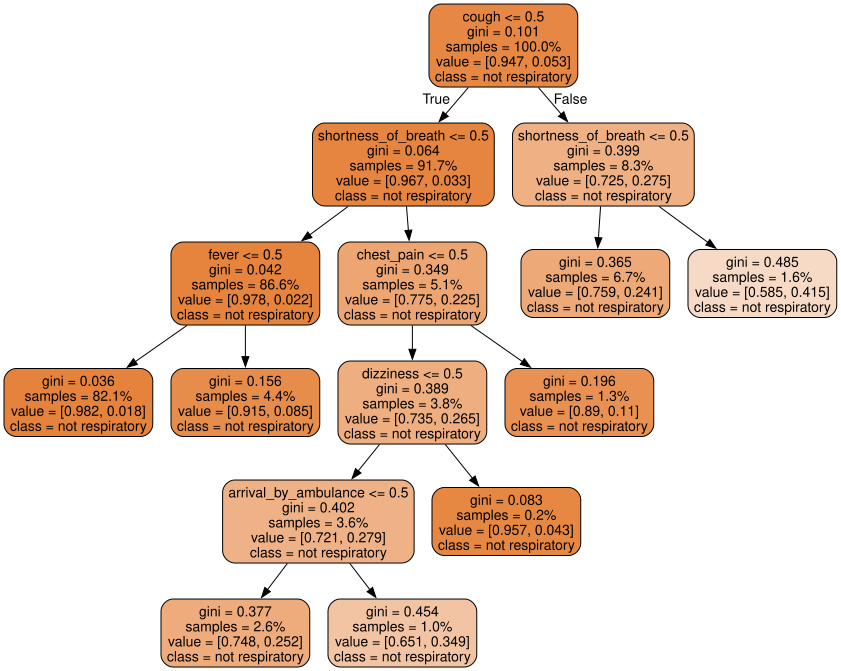

In [6]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

Which variables does the tree exploit? 

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

</div>

# Answers

### Most/least likely combinations for respiratory in the traning data is about 5.3%. 
- Least Likely: patients with no cough, no shortness of breath, and no fear fall into the largest leaf where p = 1.8%
- Most likely: patients with both coughs and shortness of breath have a p = 41.5% which is roughly 8x the base rate of 5.3%

### Variables
- cough, shortness_of_breath, fever, chest_pain, dizziness, and arrival_by_ambulance. Looking at this all of the variables relate to breathing problems plus context on how the patient arrived. In this there is nothing about the age or sex which are things that identify the patient. 

### Conditional Updating
- So we start with no information about the patient so all we can assume is that 5.3 of visits in this dataset are respiratory. This is our guess and then from there we ask whether this patient has had a cough which will then match patients who did (27.5%) or didn't (2%) cough. This one piece of information let's change the direction which is where the conditional updating aspect comes to play. The more information we get the more narrower we get to determine the final reason why they are seeking a visit. Following the information of the cough we can look at people who has a cough and ask if they have shortness of breath. If they have a cough and shortness of breath there is a 41.5% chance it's respiratory. So overall each new piece of information we get narrows the group to provide the best estimate. That's what the decision treat is doing at a high level. 


In [11]:
# rerunning code with different min_impurity_decrease (1e-3)
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
#graph

In [12]:
# rerunning code with different min_impurity_decrease (1e-5)
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-5, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
#graph

In [13]:
# rerunning code with different min_impurity_decrease (1e-7)
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-7, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
#graph

# Results from Rerunning code for Min_impurity_decrease changes

### Results
- As min_impurity_decrease get's smaller the number questions that get's asked increases even if it mariginally helps. The higher we got like the 1e-3 that means the questions being asked are questions that help narrow things down. So as a result of all of this we see that there is more leaves increase the more smaller we get which is why there are so many splits. 

#### 1e-3
- the lowest p(respiratory) is 2.2% where there is no cough and no shortness of breath. The highest is 27.5% where there is only a cough
#### 1e-5
- the lowest p(respiratory) is 0.0% where there is no cough, shortness of breath, fever, chest pain, but there is an accident. The highest is 55.5% where there is a cough and shortness of breath, no chest pain, no headache, and the age is above 70, and sex = 0.

#### 1e-7
- the lowest p(respiratory) is 0.0% where there is no cough, shortness of breath, fever, chest pain, but there is an accident. The highest is 57.7% where there is a cough and shortness of breath, no chest pain, no headache, the age is above 70, sex is = 0, and the patient didn't arrive by an ambulance. 


<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

</div>

In [18]:
# rerunning code with disease as neurological and then different min_impurity_decrease (1e-3)
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
#graph

In [20]:
# rerunning code with disease as neurological and then different min_impurity_decrease (1e-5)
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-5, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
#graph

In [16]:
# rerunning code with disease as neurological and then different min_impurity_decrease (1e-7)
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-7, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
#graph

# Results from Rerunning code for Min_impurity_decrease changes and nuerological as the disease


### Understanding Nuerological Disease
Looking at the neurological training data the base rate is 1.83% which just means it's a lot rarer than the respiratory diseases. 

#### Differences
In the respiratory case at the highest threshold of 1e-3 we saw a split in the tree but in the nuerological case we don't see a split. There is only a single node no matter the symptoms of the patient. However like we saw in the respiratory case the more we smaller we get the more splits and leaves we get. 

#### Variables
1e-5: headache, age_u20, accident, shortness_of_breath, cough, fever, chest_pain, back_pain, abdominal_pain, sex, age_40_60, age_o70, dizziness, and arrival_by_ambulance.

1e-7: all the 1e-5 and age_20_40, age_60_70, anxiety, nausea, skin_rash, and vomiting. 

- Increases probability: having a headache and being in the age_40_60 group 
- Decreases probability: yes to: accident, fever, cough, shortness_of_breath, chest_pain, and back_pain

#### Results 
- 1e-3: lowest is 1.83% and no split which is also the highest 
- 1e-5: lowest is 0.0% where you have no headache, older than 20 years, and have had an accident and the highest is 18.5% where you have headache but no fever, no accident, no cough, no chest pain, no back pain, no abdominal pain, and you are between 40 - 60 years old 
- 1e-7: lowest is 0.0% where you have no headache, older than 20 years, no accident, no shortness of breath, no cough, didn't arrive by ambulance, no chest pain, not age 20-40, but you do have a skin rash. The highest is 18.5% where you have headache but no fever, no accident, no cough, no chest pain, no back pain, no abdominal pain, and you are between 40 - 60 years old 

#### Overall Analysis
- Just like what we saw in the respiratory side of things the lower the threshold the more questions being asked so there is more splits. But again you also need a lower threshold to see anything anyway. Comparing it to the respiratory neurological diseases are much rarer compared to respiratory too. 

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

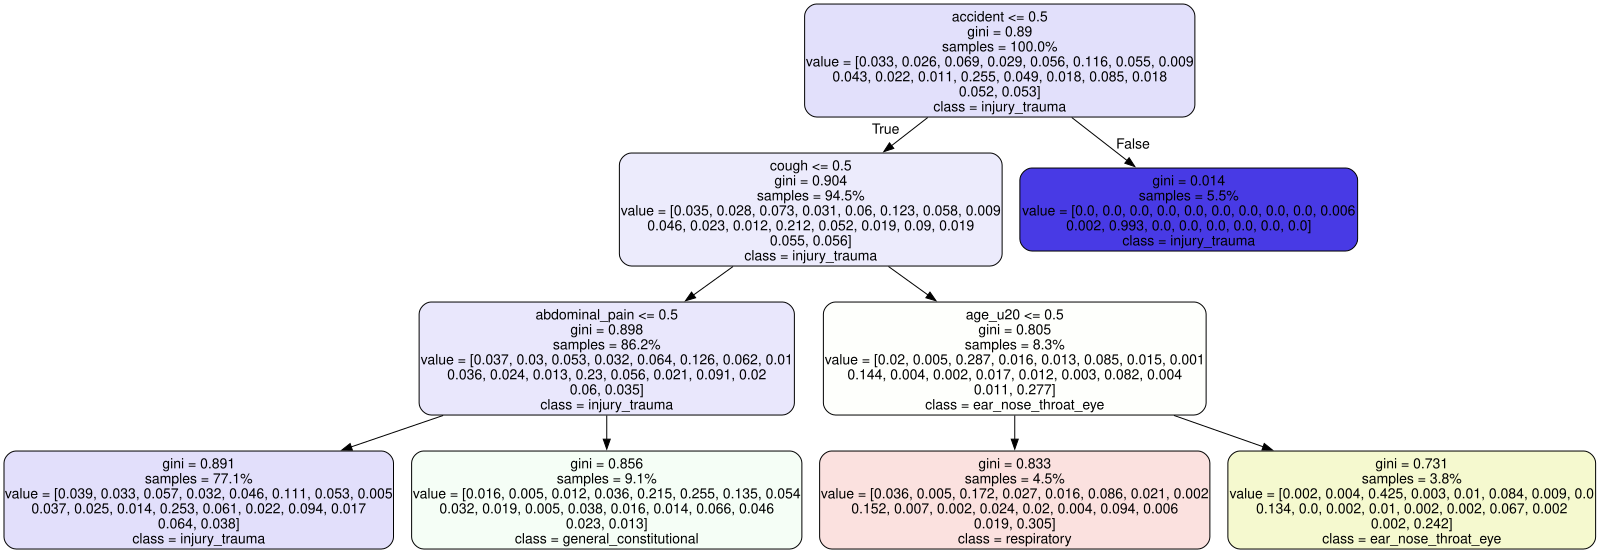

In [10]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

Which conditions and values are used in the tree?

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

</div>

# Answer 

#### Diseases hard to classify
- The diseases hard to classify are injury_trauma, general_constitutional, respiratory, and ear_nose_throat_eye. Of these 5 only one that exceeds .5 and most don't even pass .3. injury_trauma is well under .3, general_constitutional is well under .3, respiratory is just barely over .3, and ear_nose_throat_eye is over .3 but under .5. the "had and accident" is the only that is over .5. It looks like the tree is picking one node even when it's just the most common guess out of the options. This results in most patients having wrong guesses 3 out of 4 times. 

#### Highest and lowest probabilities
- Highest: injury_trauma at 99.3% for the yes you had an accident
- Lowest: injury_trauma is also the lowest at 25.3% for no you didn't have an accident but you also had no cough and no abdominal pain. 

#### Conditions
- 4 variables show up across the tree as just yes or no ( <= .5 and > 0.5 ) splits to the tree:
    - accident 
    - cough
    - abdominal_pain
    - age_u20

#### Usefulness for Doctors
- It's still a useful tool to have some sort of direction than blindly guessing. Although it might not be completely accurate it helps narrow even if you aren't able to make a certain judgement. This is also a tool to be helpful and not the final diagnoses which would help the doctor decide what to test or ask about first. 